# 1. Project Overview

This notebook rebuilds RFM customer analysis from the processed datasets in `data/processed/`. The prior RFM notebook is treated only as a reference artifact; all calculations, segment rules, visualizations, and recommendations are derived from the available cleaned data.

RFM analysis uses completed customer transactions to summarize how recently customers purchased, how often they purchased, and how much completed net revenue they generated.

# 2. Import Libraries

The notebook uses production-oriented Python utilities for logging and validation, `pandas` and `numpy` for analysis, and only `matplotlib` plus `seaborn` for required visualizations. `squarify` is optional and used only when installed.

In [27]:
from __future__ import annotations

import logging
import warnings
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import squarify

    SQUARIFY_AVAILABLE = True
except ImportError:
    SQUARIFY_AVAILABLE = False

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")

# 3. Configuration

All paths, logging settings, source-column names, scoring settings, and output locations are declared centrally. Figures are written to `outputs/figures/`; analytical tables are written to `outputs/`.

In [28]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CUSTOMER_ID_COLUMN = "customer_id"
TRANSACTION_DATE_COLUMN = "transaction_date"
TRANSACTION_ID_COLUMN = "transaction_id"
TRANSACTION_STATUS_COLUMN = "transaction_status"
REVENUE_COLUMN = "net_revenue"
COMPLETED_STATUS = "Completed"
RFM_SCORE_BINS = 5
TOP_CUSTOMER_LIMIT = 100
LOW_VALUE_CUSTOMER_LIMIT = 500

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
)
logger = logging.getLogger("rfm_analysis")

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.4f}".format)

# 4. Load Processed Data

Every cleaned CSV under `data/processed/` is discovered and loaded. RFM requires a customer identifier, transaction date, transaction identifier, and monetary value; the transaction dataset provides these fields and the customer dataset provides additional descriptive and value context.

In [29]:
def load_processed_csvs(data_dir: Path) -> Dict[str, pd.DataFrame]:
    """Load all processed CSV files from the configured directory."""
    if not data_dir.exists():
        raise FileNotFoundError(f"Processed data directory not found: {data_dir}")

    csv_paths = sorted(data_dir.glob("*.csv"))
    if not csv_paths:
        raise FileNotFoundError(f"No processed CSV files found in: {data_dir}")

    datasets: Dict[str, pd.DataFrame] = {}
    for path in csv_paths:
        try:
            datasets[path.name] = pd.read_csv(path)
            logger.info("Loaded %s with shape %s", path.name, datasets[path.name].shape)
        except Exception as exc:
            logger.exception("Failed to load %s", path.name)
            raise RuntimeError(f"Unable to load {path.name}") from exc
    return datasets


def find_dataset(
    datasets: Dict[str, pd.DataFrame],
    required_columns: Iterable[str],
    preferred_name: Optional[str] = None,
) -> Optional[pd.DataFrame]:
    """Return a copy of the first dataset containing all required columns."""
    required = set(required_columns)
    if preferred_name in datasets and required.issubset(datasets[preferred_name].columns):
        return datasets[preferred_name].copy()

    for data in datasets.values():
        if required.issubset(data.columns):
            return data.copy()
    return None


def build_dataset_inventory(datasets: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Create a compact inventory of loaded processed datasets."""
    records = []
    for name, data in datasets.items():
        records.append(
            {
                "dataset": name,
                "rows": data.shape[0],
                "columns": data.shape[1],
                "missing_values": int(data.isna().sum().sum()),
                "duplicate_rows": int(data.duplicated().sum()),
                "unique_customers": int(data[CUSTOMER_ID_COLUMN].nunique())
                if CUSTOMER_ID_COLUMN in data.columns
                else np.nan,
            }
        )
    return pd.DataFrame(records).sort_values("dataset").reset_index(drop=True)


processed_data = load_processed_csvs(DATA_DIR)
customers_raw = find_dataset(
    processed_data,
    required_columns=[CUSTOMER_ID_COLUMN],
    preferred_name="financial_customers_clean.csv",
)
transactions_raw = find_dataset(
    processed_data,
    required_columns=[CUSTOMER_ID_COLUMN, TRANSACTION_DATE_COLUMN],
    preferred_name="financial_transactions_clean.csv",
)

if customers_raw is None:
    raise ValueError("A customer dataset with customer_id is required for RFM context.")
if transactions_raw is None:
    raise ValueError("A transaction dataset with customer_id and transaction_date is required for RFM.")

display(build_dataset_inventory(processed_data))

2026-07-08 22:39:34,601 - INFO - Loaded financial_customers_clean.csv with shape (20000, 36)
2026-07-08 22:39:35,263 - INFO - Loaded financial_transactions_clean.csv with shape (329202, 30)
2026-07-08 22:39:35,266 - INFO - Loaded monthly_revenue_clean.csv with shape (36, 18)


,dataset,rows,columns,missing_values,duplicate_rows,unique_customers
0,financial_customers_clean.csv,20000,36,0,0,20000.0000
1,financial_transactions_clean.csv,329202,30,0,0,20000.0000
2,monthly_revenue_clean.csv,36,18,0,0,NaN


# 5. Business Problem

The business needs a practical way to prioritize customers for retention, expansion, reactivation, and value protection. RFM analysis groups customers by completed purchase recency, purchase frequency, and completed net revenue so marketing and customer teams can match action plans to customer value and engagement patterns.

# 6. RFM Business Explanation

RFM uses three customer-level measures:

- **Recency:** days since the latest completed transaction. Lower recency is better.
- **Frequency:** count of completed transactions. Higher frequency is better.
- **Monetary:** total completed net revenue. Higher monetary value is better.

The processed transaction dataset contains the required columns: `customer_id`, `transaction_date`, `transaction_id`, `transaction_status`, and `net_revenue`. The analysis uses completed transactions only because failed transactions are not realized purchases and refunded transactions are not durable revenue. Average order value is derived as monetary value divided by frequency.

# 7. Data Preparation

This section validates the RFM source columns, filters to completed transactions, parses dates, and attaches optional customer context such as geography, subscription plan, usage, support, and customer lifetime value.

In [30]:
def validate_rfm_columns(transactions: pd.DataFrame) -> pd.DataFrame:
    """Validate and document source columns used for RFM analysis."""
    required_columns = [CUSTOMER_ID_COLUMN, TRANSACTION_DATE_COLUMN]
    missing_required = [column for column in required_columns if column not in transactions.columns]
    if missing_required:
        raise ValueError(f"Missing required RFM columns: {missing_required}")

    records = [
        {
            "rfm_component": "customer_identifier",
            "source_column": CUSTOMER_ID_COLUMN,
            "status": "available",
            "assumption": "One customer_id identifies one customer across transactions and customer records.",
        },
        {
            "rfm_component": "recency",
            "source_column": TRANSACTION_DATE_COLUMN,
            "status": "available",
            "assumption": "Latest completed transaction date represents most recent purchase activity.",
        },
    ]

    if TRANSACTION_ID_COLUMN in transactions.columns:
        frequency_source = TRANSACTION_ID_COLUMN
        frequency_status = "available"
        frequency_assumption = "Frequency is the count of completed transaction_id records."
    else:
        frequency_source = "row_count"
        frequency_status = "derived"
        frequency_assumption = "transaction_id is unavailable, so frequency is derived from completed transaction rows."

    if REVENUE_COLUMN in transactions.columns:
        monetary_source = REVENUE_COLUMN
        monetary_status = "available"
        monetary_assumption = "Monetary value is completed transaction net revenue."
    else:
        monetary_source = "gross_amount"
        monetary_status = "fallback" if "gross_amount" in transactions.columns else "missing"
        monetary_assumption = "net_revenue is unavailable; gross_amount is the fallback monetary value."

    records.extend(
        [
            {
                "rfm_component": "frequency",
                "source_column": frequency_source,
                "status": frequency_status,
                "assumption": frequency_assumption,
            },
            {
                "rfm_component": "monetary",
                "source_column": monetary_source,
                "status": monetary_status,
                "assumption": monetary_assumption,
            },
        ]
    )
    return pd.DataFrame(records)


def prepare_transaction_data(transactions: pd.DataFrame) -> pd.DataFrame:
    """Prepare transaction records for RFM calculations."""
    data = transactions.copy()
    data[TRANSACTION_DATE_COLUMN] = pd.to_datetime(data[TRANSACTION_DATE_COLUMN], errors="coerce")
    if data[TRANSACTION_DATE_COLUMN].isna().any():
        raise ValueError("Some transaction_date values could not be parsed.")

    if TRANSACTION_STATUS_COLUMN in data.columns:
        data = data[data[TRANSACTION_STATUS_COLUMN].eq(COMPLETED_STATUS)].copy()
        logger.info("Filtered to completed transactions: %s rows", len(data))
    else:
        logger.warning("transaction_status is unavailable; all transactions are treated as completed.")

    if REVENUE_COLUMN not in data.columns:
        if "gross_amount" in data.columns:
            data[REVENUE_COLUMN] = pd.to_numeric(data["gross_amount"], errors="coerce").fillna(0.0)
            logger.warning("net_revenue missing; using gross_amount as monetary fallback.")
        else:
            raise ValueError("Neither net_revenue nor gross_amount is available for monetary calculation.")

    if TRANSACTION_ID_COLUMN not in data.columns:
        data[TRANSACTION_ID_COLUMN] = data.index.astype(str)
        logger.warning("transaction_id missing; row index is used as transaction identifier.")

    data[REVENUE_COLUMN] = pd.to_numeric(data[REVENUE_COLUMN], errors="coerce").fillna(0.0)
    data = data[data[CUSTOMER_ID_COLUMN].notna()].copy()
    return data


rfm_column_audit = validate_rfm_columns(transactions_raw)
transactions = prepare_transaction_data(transactions_raw)
customers = customers_raw.drop_duplicates(subset=[CUSTOMER_ID_COLUMN]).copy()

display(rfm_column_audit)
print(f"Completed transaction rows used for RFM: {len(transactions):,}")
print(f"Customers with completed transactions: {transactions[CUSTOMER_ID_COLUMN].nunique():,}")

2026-07-08 22:39:35,844 - INFO - Filtered to completed transactions: 309523 rows


,rfm_component,source_column,status,assumption
0,customer_identifier,customer_id,available,One customer_id identifies one customer across...
1,recency,transaction_date,available,Latest completed transaction date represents m...
2,frequency,transaction_id,available,Frequency is the count of completed transactio...
3,monetary,net_revenue,available,Monetary value is completed transaction net re...


Completed transaction rows used for RFM: 309,523
Customers with completed transactions: 20,000


# 8. Reference Date Selection

The reference date is the day after the latest completed transaction date. This avoids zero-day recency for customers who purchased on the final observed date and creates a stable analysis snapshot.

In [31]:
def select_reference_date(transactions: pd.DataFrame) -> pd.Timestamp:
    """Select the RFM reference date from completed transaction history."""
    latest_transaction_date = transactions[TRANSACTION_DATE_COLUMN].max()
    if pd.isna(latest_transaction_date):
        raise ValueError("Cannot select a reference date because transaction dates are unavailable.")
    return latest_transaction_date + pd.Timedelta(days=1)


reference_date = select_reference_date(transactions)
reference_date_summary = pd.DataFrame(
    [
        {
            "earliest_completed_transaction": transactions[TRANSACTION_DATE_COLUMN].min(),
            "latest_completed_transaction": transactions[TRANSACTION_DATE_COLUMN].max(),
            "reference_date": reference_date,
            "assumption": "Reference date is one day after the latest completed transaction.",
        }
    ]
)
display(reference_date_summary)

,earliest_completed_transaction,latest_completed_transaction,reference_date,assumption
0,2022-01-03,2024-12-31,2025-01-01,Reference date is one day after the latest com...


# 9. Recency Calculation

Recency is calculated for each customer as the number of days between the reference date and their latest completed transaction date. Lower recency means more recent engagement.

In [32]:
def calculate_recency(transactions: pd.DataFrame, reference_date: pd.Timestamp) -> pd.DataFrame:
    """Calculate days since each customer's latest completed transaction."""
    recency = (
        transactions.groupby(CUSTOMER_ID_COLUMN)[TRANSACTION_DATE_COLUMN]
        .max()
        .rename("last_completed_transaction_date")
        .reset_index()
    )
    recency["recency"] = (
        reference_date - recency["last_completed_transaction_date"]
    ).dt.days.astype(int)
    return recency


recency_table = calculate_recency(transactions, reference_date)
recency_summary = pd.DataFrame(
    [
        {
            "customers": len(recency_table),
            "earliest_last_completed_transaction": recency_table["last_completed_transaction_date"].min(),
            "latest_last_completed_transaction": recency_table["last_completed_transaction_date"].max(),
            "average_recency": recency_table["recency"].mean(),
            "median_recency": recency_table["recency"].median(),
            "maximum_recency": recency_table["recency"].max(),
        }
    ]
)
display(recency_summary)

,customers,earliest_last_completed_transaction,latest_last_completed_transaction,average_recency,median_recency,maximum_recency
0,20000,2022-03-21,2024-12-31,81.0721,36.0000,1017


# 10. Frequency Calculation

Frequency is the count of completed transactions per customer. Higher frequency indicates stronger repeat purchase behavior.

In [33]:
def calculate_frequency(transactions: pd.DataFrame) -> pd.DataFrame:
    """Calculate completed transaction count for each customer."""
    frequency = (
        transactions.groupby(CUSTOMER_ID_COLUMN)[TRANSACTION_ID_COLUMN]
        .nunique()
        .rename("frequency")
        .reset_index()
    )
    return frequency


frequency_table = calculate_frequency(transactions)
display(frequency_table["frequency"].describe().to_frame().T)

,count,mean,std,min,25%,50%,75%,max
frequency,20000.0000,15.4762,3.0070,4.0000,13.0000,16.0000,17.0000,27.0000


# 11. Monetary Calculation

Monetary value is the sum of completed transaction net revenue per customer. Average order value is derived after the RFM table is created.

In [34]:
def calculate_monetary(transactions: pd.DataFrame) -> pd.DataFrame:
    """Calculate completed net revenue for each customer."""
    monetary = (
        transactions.groupby(CUSTOMER_ID_COLUMN)[REVENUE_COLUMN]
        .sum()
        .rename("monetary")
        .reset_index()
    )
    return monetary


monetary_table = calculate_monetary(transactions)
display(monetary_table["monetary"].describe().to_frame().T)

,count,mean,std,min,25%,50%,75%,max
monetary,20000.0000,26384.2122,59190.4398,203.2700,1334.9275,4028.3650,15916.1100,524421.1000


# 12. RFM Table Creation

The RFM table combines recency, frequency, monetary value, average order value, and available customer context into one customer-level analytical table.

In [35]:
def build_rfm_table(
    customers: pd.DataFrame,
    recency: pd.DataFrame,
    frequency: pd.DataFrame,
    monetary: pd.DataFrame,
) -> pd.DataFrame:
    """Create the customer-level RFM table with available context columns."""
    rfm = customers[[CUSTOMER_ID_COLUMN]].copy()
    rfm = rfm.merge(recency, on=CUSTOMER_ID_COLUMN, how="left")
    rfm = rfm.merge(frequency, on=CUSTOMER_ID_COLUMN, how="left")
    rfm = rfm.merge(monetary, on=CUSTOMER_ID_COLUMN, how="left")

    rfm["frequency"] = rfm["frequency"].fillna(0).astype(int)
    rfm["monetary"] = rfm["monetary"].fillna(0.0)
    rfm["recency"] = rfm["recency"].fillna((reference_date - transactions[TRANSACTION_DATE_COLUMN].min()).days)
    rfm["average_order_value"] = np.where(
        rfm["frequency"] > 0,
        rfm["monetary"] / rfm["frequency"],
        0.0,
    )

    context_columns = [
        "country",
        "region",
        "industry",
        "company_size",
        "subscription_plan",
        "contract_type",
        "monthly_recurring_revenue",
        "customer_lifetime_value",
        "support_tickets",
        "usage_score",
        "login_frequency",
        "nps_score",
        "discount_percentage",
        "tenure_months",
        "customer_acquisition_cost",
    ]
    available_context = [column for column in context_columns if column in customers.columns]
    if available_context:
        rfm = rfm.merge(
            customers[[CUSTOMER_ID_COLUMN] + available_context],
            on=CUSTOMER_ID_COLUMN,
            how="left",
        )
    return rfm


rfm_table = build_rfm_table(customers, recency_table, frequency_table, monetary_table)
print(f"RFM table rows: {len(rfm_table):,}")
display(rfm_table.head())

RFM table rows: 20,000


,customer_id,last_completed_transaction_date,recency,frequency,monetary,average_order_value,country,region,industry,company_size,subscription_plan,contract_type,monthly_recurring_revenue,customer_lifetime_value,support_tickets,usage_score,login_frequency,nps_score,discount_percentage,tenure_months,customer_acquisition_cost
0,CUST_000000,2024-11-27,35,15,122960.0100,8197.3340,Germany,Europe,Healthcare,Mid-Market,Enterprise,Annual,3820.0800,29255.4500,6.0000,48.7000,21.1000,-15.0000,8.1000,17,3707.9200
1,CUST_000001,2024-12-25,7,15,2827.2000,188.4800,India,APAC,Technology,Startup,Professional,Monthly,82.4300,228.9700,5.0000,61.0000,21.2000,8.0000,0.0000,2,75.1500
2,CUST_000002,2024-12-15,17,15,1157.7200,77.1813,UK,Europe,Technology,Startup,Basic,Monthly,38.9200,61.2600,3.0000,39.9000,12.1000,7.0000,2.1000,7,85.1000
3,CUST_000003,2024-07-09,176,13,4034.3700,310.3362,USA,North America,Technology,Small Business,Professional,Annual,185.7100,600.6800,5.0000,46.6000,14.1000,11.0000,6.2000,10,640.1400
4,CUST_000004,2023-05-20,592,11,2467.9300,224.3573,USA,North America,Technology,Small Business,Professional,Monthly,166.1300,343.3600,2.0000,29.6000,7.0000,-17.0000,4.1000,25,314.3700


# 13. RFM Score Calculation

RFM scores convert raw metrics into 1-to-5 ranks. Recency is reverse-scored because lower recency is better; frequency and monetary value are scored higher when values are higher.

In [36]:
def score_quantile(series: pd.Series, higher_is_better: bool = True, bins: int = RFM_SCORE_BINS) -> pd.Series:
    """Create stable quantile scores from 1 to bins."""
    ranked = series.rank(method="first")
    labels = list(range(1, bins + 1)) if higher_is_better else list(range(bins, 0, -1))
    try:
        return pd.qcut(ranked, q=bins, labels=labels).astype(int)
    except ValueError:
        percentile = ranked.rank(pct=True)
        raw_scores = np.ceil(percentile * bins).clip(1, bins).astype(int)
        if higher_is_better:
            return raw_scores
        return (bins + 1 - raw_scores).astype(int)


def add_rfm_scores(rfm: pd.DataFrame) -> pd.DataFrame:
    """Add recency, frequency, monetary, and combined RFM scores."""
    output = rfm.copy()
    output["recency_score"] = score_quantile(output["recency"], higher_is_better=False)
    output["frequency_score"] = score_quantile(output["frequency"], higher_is_better=True)
    output["monetary_score"] = score_quantile(output["monetary"], higher_is_better=True)
    output["rfm_score"] = (
        output["recency_score"].astype(str)
        + output["frequency_score"].astype(str)
        + output["monetary_score"].astype(str)
    )
    output["rfm_total_score"] = output[
        ["recency_score", "frequency_score", "monetary_score"]
    ].sum(axis=1)
    return output


rfm_table = add_rfm_scores(rfm_table)
display(
    rfm_table[
        [
            CUSTOMER_ID_COLUMN,
            "recency",
            "frequency",
            "monetary",
            "recency_score",
            "frequency_score",
            "monetary_score",
            "rfm_score",
            "rfm_total_score",
        ]
    ].head()
)

,customer_id,recency,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,rfm_total_score
0,CUST_000000,35,15,122960.0100,3,2,5,325,10
1,CUST_000001,7,15,2827.2000,5,2,3,523,10
2,CUST_000002,17,15,1157.7200,4,2,2,422,8
3,CUST_000003,176,13,4034.3700,1,1,3,113,5
4,CUST_000004,592,11,2467.9300,1,1,2,112,4


# 14. Customer Segmentation Rules

RFM segments are rule-based and tied directly to recency, frequency, and monetary scores. The goal is not generic clustering; it is an interpretable RFM strategy map for customer action.

In [37]:
def assign_rfm_segment(row: pd.Series) -> str:
    """Assign an interpretable RFM segment from score combinations."""
    r_score = row["recency_score"]
    f_score = row["frequency_score"]
    m_score = row["monetary_score"]

    if r_score >= 4 and f_score >= 4 and m_score >= 4:
        return "Champions"
    if r_score >= 3 and f_score >= 4 and m_score >= 4:
        return "Loyal High Value"
    if r_score <= 2 and f_score >= 4 and m_score >= 4:
        return "At Risk High Value"
    if r_score >= 4 and f_score <= 2 and m_score <= 3:
        return "New or Promising"
    if r_score >= 4 and f_score >= 3 and m_score <= 3:
        return "Potential Loyalists"
    if m_score == 5 and f_score <= 3:
        return "Big Spenders"
    if r_score <= 2 and f_score <= 2 and m_score <= 2:
        return "Low Value Dormant"
    if r_score <= 2 and (f_score >= 3 or m_score >= 3):
        return "Needs Attention"
    if r_score == 3 and f_score <= 3 and m_score <= 3:
        return "Regular Customers"
    return "Steady Customers"


def build_segment_summary(rfm: pd.DataFrame) -> pd.DataFrame:
    """Summarize size, value, and behavior by RFM segment."""
    aggregation = {
        CUSTOMER_ID_COLUMN: "nunique",
        "recency": "mean",
        "frequency": "mean",
        "monetary": ["sum", "mean"],
        "average_order_value": "mean",
        "rfm_total_score": "mean",
    }
    optional_mean_columns = [
        "customer_lifetime_value",
        "monthly_recurring_revenue",
        "usage_score",
        "login_frequency",
        "nps_score",
        "support_tickets",
        "tenure_months",
    ]
    for column in optional_mean_columns:
        if column in rfm.columns:
            aggregation[column] = "mean"

    summary = rfm.groupby("rfm_segment").agg(aggregation)
    summary.columns = [
        "_".join(column).strip("_") if isinstance(column, tuple) else column
        for column in summary.columns
    ]
    summary = summary.rename(
        columns={
            f"{CUSTOMER_ID_COLUMN}_nunique": "customers",
            "monetary_sum": "segment_revenue",
            "monetary_mean": "average_monetary",
        }
    ).reset_index()
    total_customers = summary["customers"].sum()
    total_revenue = summary["segment_revenue"].sum()
    summary["customer_share"] = summary["customers"] / total_customers
    summary["revenue_share"] = summary["segment_revenue"] / total_revenue
    return summary.sort_values("segment_revenue", ascending=False).reset_index(drop=True)


rfm_table["rfm_segment"] = rfm_table.apply(assign_rfm_segment, axis=1)
segment_summary = build_segment_summary(rfm_table)
customer_segments = rfm_table.copy()

display(segment_summary)

,rfm_segment,customers,recency_mean,frequency_mean,segment_revenue,average_monetary,average_order_value_mean,rfm_total_score_mean,customer_lifetime_value_mean,monthly_recurring_revenue_mean,usage_score_mean,login_frequency_mean,nps_score_mean,support_tickets_mean,tenure_months_mean,customer_share,revenue_share
0,Big Spenders,2183,47.6212,13.7540,226179690.9600,103609.5698,7629.3297,10.3628,132460.2769,4599.5118,70.4105,21.0470,20.7751,3.1182,13.4929,0.1091,0.4286
1,Champions,1791,14.6806,18.5930,149310863.1500,83367.3161,4494.9390,13.6655,63912.6601,2470.1975,65.6180,19.8486,18.2903,3.3456,7.6745,0.0896,0.2830
2,Loyal High Value,804,36.1455,18.3184,56221832.7100,69927.6526,3846.2360,12.0697,68917.3888,2493.8967,64.8096,19.3759,16.7848,3.3520,19.8209,0.0402,0.1065
3,At Risk High Value,823,147.3402,18.1495,38655769.9300,46969.3438,2616.0469,10.3985,46217.1089,1771.3245,59.1911,17.4055,11.2928,3.6501,20.6501,0.0411,0.0733
4,Needs Attention,4460,179.6670,15.7170,20943744.6200,4695.9069,336.5119,7.1632,1786.4308,218.8526,50.8823,15.1180,5.2072,3.9592,19.2908,0.2230,0.0397
5,Steady Customers,2322,28.0672,15.5357,20373175.7300,8773.9775,634.4749,9.8829,3429.7244,353.4070,58.1839,17.6356,12.9053,3.5469,13.1357,0.1161,0.0386
6,Potential Loyalists,2781,15.5609,17.4750,7417014.8400,2667.0316,153.6233,10.7238,356.5229,78.6559,52.9195,16.0485,9.8483,3.7044,7.3952,0.1391,0.0141
7,New or Promising,1504,15.9827,12.7287,3367864.2900,2239.2715,177.7276,7.9900,414.3105,88.3366,53.7378,16.2380,10.3551,3.7440,5.5805,0.0752,0.0064
8,Regular Customers,1324,36.2092,13.5838,2834213.5700,2140.6447,160.2614,6.9320,459.3297,91.9167,53.3161,16.1240,8.5816,3.7757,14.1745,0.0662,0.0054
9,Low Value Dormant,2008,178.8491,12.2679,2380074.4900,1185.2961,98.1132,4.3461,243.0083,62.1241,48.2841,14.2215,4.0359,3.9920,19.3845,0.1004,0.0045


# 15. Segment Distribution

Segment distribution shows how the customer base is distributed across RFM groups. This helps size each marketing and account-management motion.

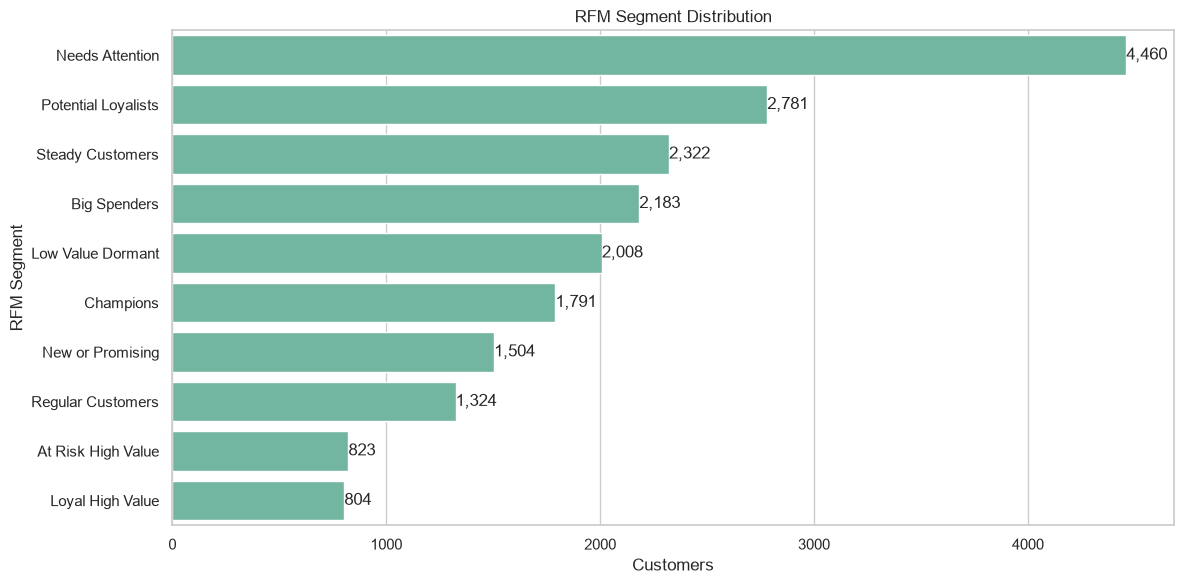

2026-07-08 22:39:36,492 - INFO - Segment Distribution insight: Needs Attention is the largest segment with 4,460 customers.


Business insight - Segment Distribution: Needs Attention is the largest segment with 4,460 customers.


In [38]:
business_insights: List[Dict[str, str]] = []


def add_business_insight(section: str, insight: str) -> None:
    """Store and print an insight from an analytical step."""
    business_insights.append({"section": section, "insight": insight})
    logger.info("%s insight: %s", section, insight)
    print(f"Business insight - {section}: {insight}")


segment_distribution = segment_summary.sort_values("customers", ascending=False)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.barplot(
    data=segment_distribution,
    x="customers",
    y="rfm_segment",
    ax=ax,
)
ax.set_title("RFM Segment Distribution")
ax.set_xlabel("Customers")
ax.set_ylabel("RFM Segment")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "rfm_segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

largest_segment = segment_distribution.iloc[0]
add_business_insight(
    "Segment Distribution",
    f"{largest_segment['rfm_segment']} is the largest segment with "
    f"{int(largest_segment['customers']):,} customers."
)

# 16. Revenue Contribution by Segment

Revenue contribution identifies which RFM segments generate the largest share of completed net revenue.

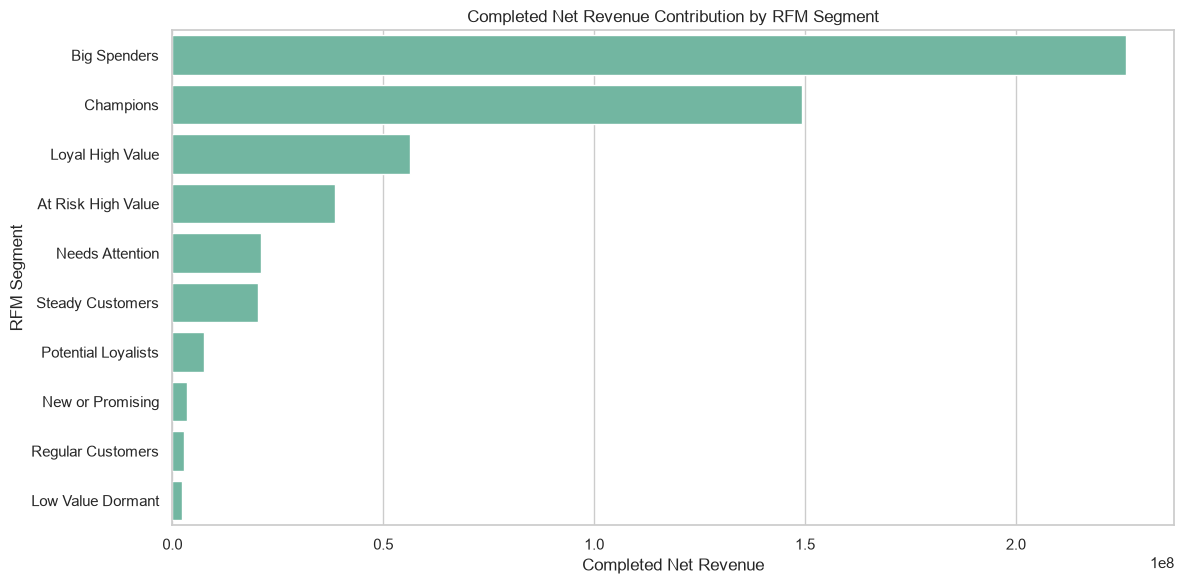

2026-07-08 22:39:36,755 - INFO - Revenue Contribution insight: Big Spenders contributes the most completed net revenue at 42.9% of analyzed revenue.


Business insight - Revenue Contribution: Big Spenders contributes the most completed net revenue at 42.9% of analyzed revenue.


In [39]:
revenue_contribution = segment_summary.sort_values("segment_revenue", ascending=False)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.barplot(
    data=revenue_contribution,
    x="segment_revenue",
    y="rfm_segment",
    ax=ax,
)
ax.set_title("Completed Net Revenue Contribution by RFM Segment")
ax.set_xlabel("Completed Net Revenue")
ax.set_ylabel("RFM Segment")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "rfm_revenue_contribution_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

highest_revenue_segment = revenue_contribution.iloc[0]
add_business_insight(
    "Revenue Contribution",
    f"{highest_revenue_segment['rfm_segment']} contributes the most completed net revenue "
    f"at {highest_revenue_segment['revenue_share']:.1%} of analyzed revenue."
)

# 17. Customer Value Analysis

Customer value analysis compares segment-level monetary value and customer lifetime value when available. This clarifies whether current completed revenue and longer-term value point to the same priority groups.

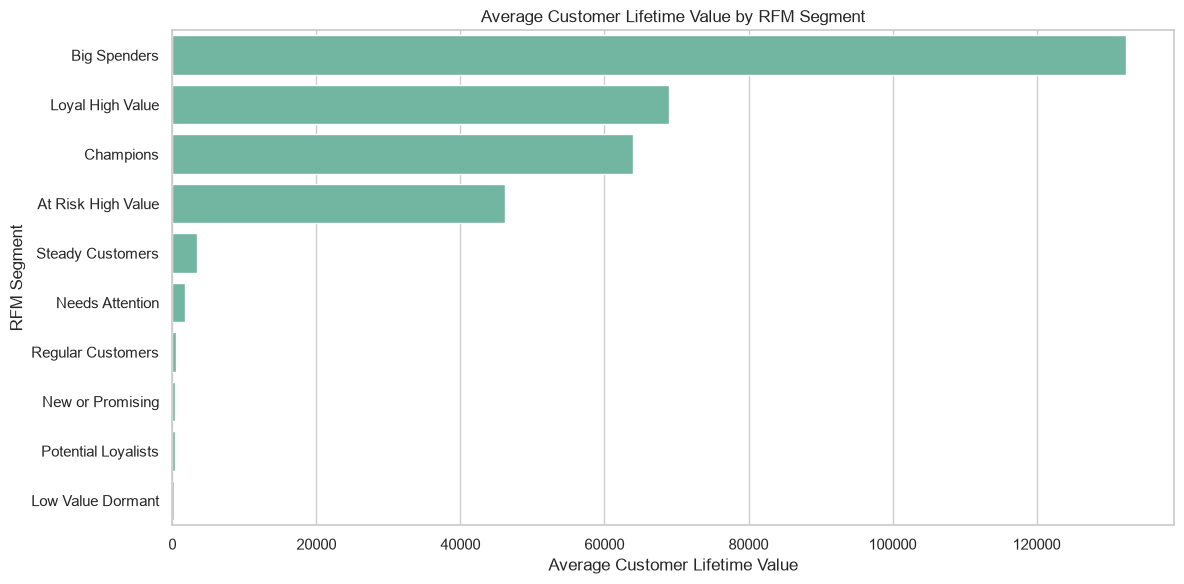

2026-07-08 22:39:37,028 - INFO - Customer Value Analysis insight: Big Spenders has the highest average customer lifetime value among RFM segments.


Business insight - Customer Value Analysis: Big Spenders has the highest average customer lifetime value among RFM segments.


In [40]:
if "customer_lifetime_value_mean" in segment_summary.columns:
    value_metric = "customer_lifetime_value_mean"
    value_label = "Average Customer Lifetime Value"
else:
    value_metric = "average_monetary"
    value_label = "Average Completed Net Revenue"

customer_value_plot = segment_summary.sort_values(value_metric, ascending=False)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.barplot(
    data=customer_value_plot,
    x=value_metric,
    y="rfm_segment",
    ax=ax,
)
ax.set_title(f"{value_label} by RFM Segment")
ax.set_xlabel(value_label)
ax.set_ylabel("RFM Segment")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "rfm_customer_value_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

highest_value_segment = customer_value_plot.iloc[0]
add_business_insight(
    "Customer Value Analysis",
    f"{highest_value_segment['rfm_segment']} has the highest {value_label.lower()} "
    f"among RFM segments."
)

# 18. Average Order Value Analysis

Average order value is derived as completed net revenue divided by completed transaction count. This separates high-frequency customers from customers who place fewer but larger orders.

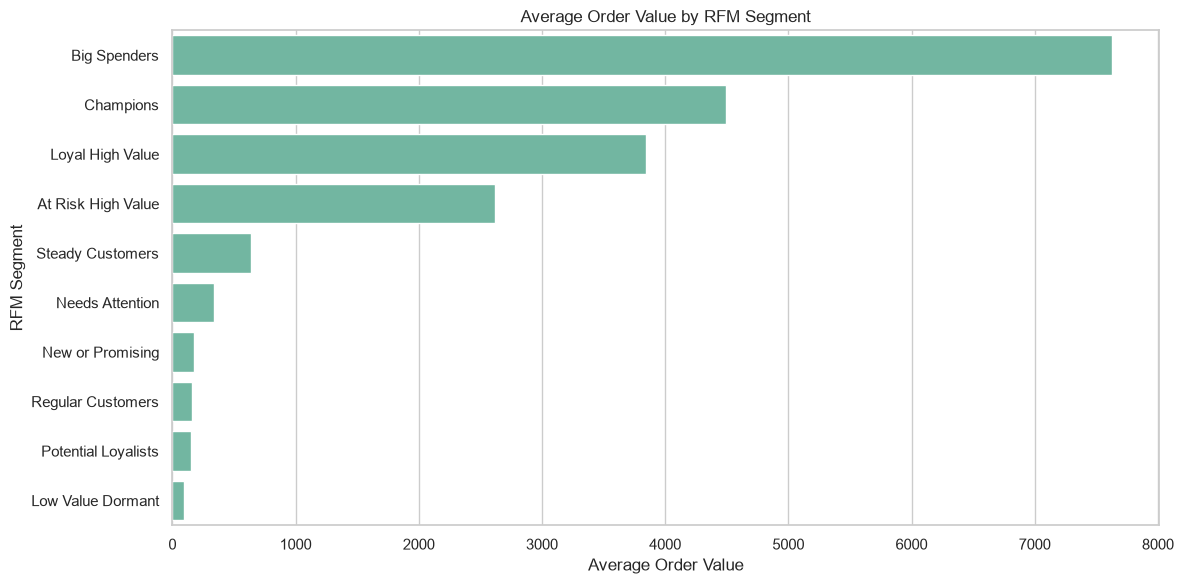

2026-07-08 22:39:37,324 - INFO - Average Order Value insight: Big Spenders has the highest average order value, which may indicate larger deal sizes or premium plan concentration.


Business insight - Average Order Value: Big Spenders has the highest average order value, which may indicate larger deal sizes or premium plan concentration.


In [41]:
aov_plot = segment_summary.sort_values("average_order_value_mean", ascending=False)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.barplot(
    data=aov_plot,
    x="average_order_value_mean",
    y="rfm_segment",
    ax=ax,
)
ax.set_title("Average Order Value by RFM Segment")
ax.set_xlabel("Average Order Value")
ax.set_ylabel("RFM Segment")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "rfm_average_order_value_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

highest_aov_segment = aov_plot.iloc[0]
add_business_insight(
    "Average Order Value",
    f"{highest_aov_segment['rfm_segment']} has the highest average order value, "
    "which may indicate larger deal sizes or premium plan concentration."
)

# 19. Segment-wise Behaviour Analysis

Segment-wise behavior compares customer engagement and support indicators where available. These signals help tailor actions beyond the core RFM metrics.

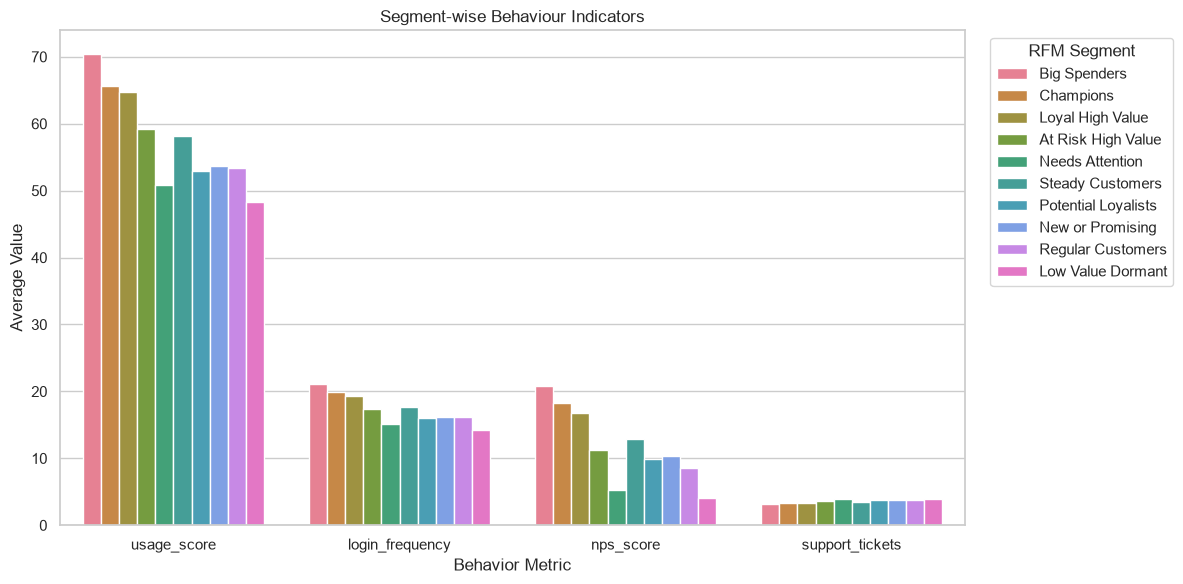

2026-07-08 22:39:37,808 - INFO - Segment-wise Behaviour insight: Engagement and support indicators vary by RFM segment, supporting differentiated customer actions.


Business insight - Segment-wise Behaviour: Engagement and support indicators vary by RFM segment, supporting differentiated customer actions.


In [42]:
behavior_columns = [
    column
    for column in ["usage_score", "login_frequency", "nps_score", "support_tickets"]
    if f"{column}_mean" in segment_summary.columns
]

if behavior_columns:
    behavior_summary = segment_summary[
        ["rfm_segment"] + [f"{column}_mean" for column in behavior_columns]
    ].copy()
    behavior_summary = behavior_summary.melt(
        id_vars="rfm_segment",
        var_name="behavior_metric",
        value_name="average_value",
    )
    behavior_summary["behavior_metric"] = behavior_summary["behavior_metric"].str.replace("_mean", "", regex=False)

    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot
    sns.barplot(
        data=behavior_summary,
        x="behavior_metric",
        y="average_value",
        hue="rfm_segment",
        ax=ax,
    )
    ax.set_title("Segment-wise Behaviour Indicators")
    ax.set_xlabel("Behavior Metric")
    ax.set_ylabel("Average Value")
    ax.legend(title="RFM Segment", bbox_to_anchor=(1.02, 1), loc="upper left")

    # Improve layout
    plt.tight_layout()

    # Save
    plt.savefig(
        FIGURES_DIR / "rfm_segment_behavior_analysis.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Show inside notebook
    plt.show()

    add_business_insight(
        "Segment-wise Behaviour",
        "Engagement and support indicators vary by RFM segment, supporting differentiated customer actions."
    )
else:
    behavior_summary = pd.DataFrame()
    logger.info("No behavior columns were available for segment-wise behavior analysis.")
    print("No behavior columns were available for segment-wise behavior analysis.")

# 20. RFM Heatmap

The RFM heatmap compares average monetary value across recency and frequency score combinations. It highlights where value concentrates across the RFM scoring grid.

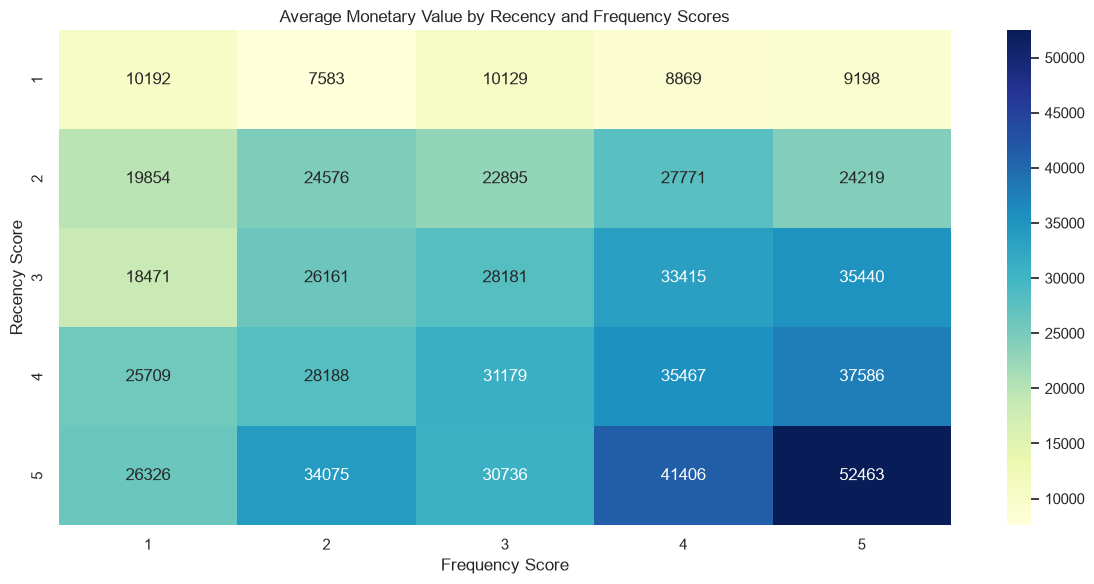

2026-07-08 22:39:38,216 - INFO - RFM Heatmap insight: The highest average monetary value appears at recency score 5 and frequency score 5.


Business insight - RFM Heatmap: The highest average monetary value appears at recency score 5 and frequency score 5.


In [43]:
rfm_heatmap_data = rfm_table.pivot_table(
    index="recency_score",
    columns="frequency_score",
    values="monetary",
    aggfunc="mean",
)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.heatmap(
    rfm_heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    ax=ax,
)
ax.set_title("Average Monetary Value by Recency and Frequency Scores")
ax.set_xlabel("Frequency Score")
ax.set_ylabel("Recency Score")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "rfm_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

max_heatmap_position = rfm_heatmap_data.stack().idxmax()
add_business_insight(
    "RFM Heatmap",
    f"The highest average monetary value appears at recency score {max_heatmap_position[0]} "
    f"and frequency score {max_heatmap_position[1]}."
)

# 21. RFM Scatter Analysis

The scatter view plots recency against monetary value with frequency represented by bubble size and segment by color. This reveals high-value customers who may need prompt attention because their most recent completed transaction is older.

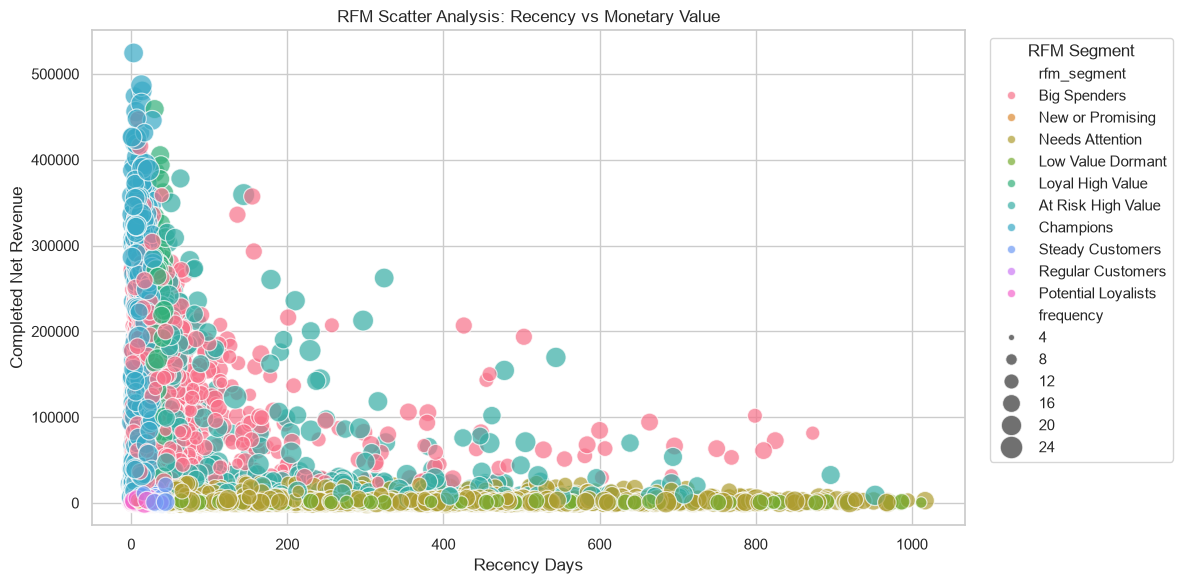

2026-07-08 22:39:39,795 - INFO - RFM Scatter Analysis insight: Customers with high monetary value and high recency should be prioritized for value-protection outreach.


Business insight - RFM Scatter Analysis: Customers with high monetary value and high recency should be prioritized for value-protection outreach.


In [44]:
scatter_sample = rfm_table.copy()

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.scatterplot(
    data=scatter_sample,
    x="recency",
    y="monetary",
    size="frequency",
    hue="rfm_segment",
    sizes=(20, 300),
    alpha=0.7,
    ax=ax,
)
ax.set_title("RFM Scatter Analysis: Recency vs Monetary Value")
ax.set_xlabel("Recency Days")
ax.set_ylabel("Completed Net Revenue")
ax.legend(title="RFM Segment", bbox_to_anchor=(1.02, 1), loc="upper left")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "rfm_scatter_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

add_business_insight(
    "RFM Scatter Analysis",
    "Customers with high monetary value and high recency should be prioritized for value-protection outreach."
)

# 22. Customer Segment Treemap (Optional)

A treemap is produced only when `squarify` is installed. If it is unavailable, the notebook skips this optional view without interrupting the workflow.

In [45]:
if SQUARIFY_AVAILABLE:
    treemap_data = segment_summary[segment_summary["customers"] > 0].copy()
    treemap_labels = [
        f"{row.rfm_segment}\n{int(row.customers):,} customers\n{row.revenue_share:.1%} revenue"
        for row in treemap_data.itertuples()
    ]

    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot
    squarify.plot(
        sizes=treemap_data["customers"],
        label=treemap_labels,
        alpha=0.85,
        ax=ax,
    )
    ax.set_title("RFM Customer Segment Treemap")
    ax.axis("off")

    # Improve layout
    plt.tight_layout()

    # Save
    plt.savefig(
        FIGURES_DIR / "rfm_customer_segment_treemap.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Show inside notebook
    plt.show()

    add_business_insight(
        "Customer Segment Treemap",
        "The treemap shows the relative customer-base footprint of each RFM segment."
    )
else:
    logger.info("squarify is not installed; skipped optional customer segment treemap.")
    print("squarify is not installed; skipped optional customer segment treemap.")

2026-07-08 22:39:39,810 - INFO - squarify is not installed; skipped optional customer segment treemap.


squarify is not installed; skipped optional customer segment treemap.


# 23. Top High Value Customers

Top high-value customers are prioritized by total RFM score, completed net revenue, frequency, and recency. These customers are strong candidates for loyalty, expansion, or executive-touch programs.

In [46]:
def select_top_customers(rfm: pd.DataFrame, limit: int = TOP_CUSTOMER_LIMIT) -> pd.DataFrame:
    """Select the highest-value customers from the RFM table."""
    columns = [
        CUSTOMER_ID_COLUMN,
        "rfm_segment",
        "rfm_score",
        "rfm_total_score",
        "recency",
        "frequency",
        "monetary",
        "average_order_value",
    ]
    optional_columns = [
        "customer_lifetime_value",
        "monthly_recurring_revenue",
        "subscription_plan",
        "contract_type",
        "country",
        "industry",
    ]
    columns.extend([column for column in optional_columns if column in rfm.columns])
    return (
        rfm[columns]
        .sort_values(
            ["rfm_total_score", "monetary", "frequency", "recency"],
            ascending=[False, False, False, True],
        )
        .head(limit)
        .reset_index(drop=True)
    )


top_customers = select_top_customers(rfm_table)
display(top_customers.head(20))

most_valuable_customer = top_customers.iloc[0]
print(
    f"Most valuable customer: {most_valuable_customer[CUSTOMER_ID_COLUMN]} "
    f"with completed net revenue of {most_valuable_customer['monetary']:,.2f}."
)

,customer_id,rfm_segment,rfm_score,rfm_total_score,recency,frequency,monetary,average_order_value,customer_lifetime_value,monthly_recurring_revenue,subscription_plan,contract_type,country,industry
0,CUST_010049,Champions,555,15,3,19,524421.1000,27601.1105,711257.1000,12080.8000,Enterprise,Monthly,USA,Education
1,CUST_008236,Champions,555,15,13,22,486487.6000,22113.0727,407789.4500,13658.0200,Enterprise,Multi-Year,USA,Retail
2,CUST_001130,Champions,555,15,14,19,480131.0200,25270.0537,70489.9000,9553.8700,Enterprise,Annual,USA,Other
3,CUST_010989,Champions,555,15,13,21,465373.5200,22160.6438,351985.2500,9523.8400,Enterprise,Annual,Canada,Technology
4,CUST_000905,Champions,555,15,6,20,456061.6300,22803.0815,767104.7800,12358.4200,Enterprise,Annual,USA,Technology
5,CUST_017723,Champions,555,15,7,18,447915.4800,24884.1933,167062.5700,9176.9700,Enterprise,Multi-Year,Germany,Healthcare
6,CUST_009513,Champions,555,15,11,19,431384.2500,22704.4342,158375.8900,10174.0400,Enterprise,Monthly,Germany,Other
7,CUST_018712,Champions,555,15,1,19,426345.0600,22439.2137,114407.4300,8676.6200,Enterprise,Monthly,Other,Finance
8,CUST_009125,Champions,555,15,4,25,426252.0800,17050.0832,68800.1800,8721.1500,Enterprise,Multi-Year,USA,Technology
9,CUST_014936,Champions,555,15,6,22,424413.5000,19291.5227,87133.3800,10267.9200,Enterprise,Annual,Germany,Finance


Most valuable customer: CUST_010049 with completed net revenue of 524,421.10.


# 24. Low Value Customer Identification

Low-value customers are identified through low RFM scores, low monetary value, and older purchase activity. This list supports low-cost reactivation, nurture, or suppression decisions.

In [47]:
def select_low_value_customers(rfm: pd.DataFrame, limit: int = LOW_VALUE_CUSTOMER_LIMIT) -> pd.DataFrame:
    """Select customers requiring attention from low RFM indicators."""
    attention_segments = ["Low Value Dormant", "Needs Attention"]
    low_value = rfm[rfm["rfm_segment"].isin(attention_segments)].copy()
    if low_value.empty:
        low_value = rfm.nsmallest(limit, ["rfm_total_score", "monetary"]).copy()

    columns = [
        CUSTOMER_ID_COLUMN,
        "rfm_segment",
        "rfm_score",
        "rfm_total_score",
        "recency",
        "frequency",
        "monetary",
        "average_order_value",
    ]
    optional_columns = [
        "usage_score",
        "login_frequency",
        "nps_score",
        "support_tickets",
        "subscription_plan",
        "contract_type",
        "country",
    ]
    columns.extend([column for column in optional_columns if column in low_value.columns])
    return (
        low_value[columns]
        .sort_values(
            ["rfm_total_score", "monetary", "recency"],
            ascending=[True, True, False],
        )
        .head(limit)
        .reset_index(drop=True)
    )


low_value_customers = select_low_value_customers(rfm_table)
display(low_value_customers.head(20))
print(f"Customers requiring attention: {len(low_value_customers):,}")

,customer_id,rfm_segment,rfm_score,rfm_total_score,recency,frequency,monetary,average_order_value,usage_score,login_frequency,nps_score,support_tickets,subscription_plan,contract_type,country
0,CUST_010120,Low Value Dormant,111,3,268,8,211.3900,26.4238,56.0000,8.0000,-2.0000,7.0000,Basic,Annual,USA
1,CUST_007605,Low Value Dormant,111,3,130,9,219.3100,24.3678,52.4000,18.7000,4.0000,5.0000,Basic,Monthly,UK
2,CUST_018179,Low Value Dormant,111,3,440,8,228.4900,28.5613,40.5000,25.5000,-35.0000,5.0000,Basic,Monthly,Australia
3,CUST_011858,Low Value Dormant,111,3,101,5,267.0800,53.4160,59.9000,19.3000,-2.0000,4.0000,Basic,Annual,Australia
4,CUST_000128,Low Value Dormant,111,3,603,9,287.5800,31.9533,49.1000,16.6000,-9.0000,6.0000,Basic,Monthly,Canada
5,CUST_011815,Low Value Dormant,111,3,333,9,295.4200,32.8244,40.3000,11.7000,-24.0000,7.0000,Basic,Monthly,Other
6,CUST_017289,Low Value Dormant,111,3,186,8,297.1600,37.1450,37.9000,9.0000,-10.0000,4.0000,Basic,Monthly,Germany
7,CUST_012729,Low Value Dormant,111,3,305,7,303.6200,43.3743,43.6000,9.0000,10.0000,2.0000,Basic,Annual,USA
8,CUST_016939,Low Value Dormant,111,3,297,11,305.7600,27.7964,61.9000,17.2000,8.0000,3.0000,Basic,Monthly,USA
9,CUST_014306,Low Value Dormant,111,3,659,10,307.9700,30.7970,34.5000,9.5000,20.0000,3.0000,Basic,Multi-Year,USA


Customers requiring attention: 500


# 25. Customer Retention Opportunities

Retention opportunities are customers with meaningful monetary value but weaker recency. They are strong candidates for win-back, renewal, education, or customer success outreach.

In [48]:
def identify_retention_opportunities(rfm: pd.DataFrame) -> pd.DataFrame:
    """Identify valuable customers whose recent activity has weakened."""
    monetary_threshold = rfm["monetary"].quantile(0.75)
    recency_threshold = rfm["recency"].quantile(0.60)
    opportunities = rfm[
        (rfm["monetary"] >= monetary_threshold)
        & (rfm["recency"] >= recency_threshold)
    ].copy()

    columns = [
        CUSTOMER_ID_COLUMN,
        "rfm_segment",
        "recency",
        "frequency",
        "monetary",
        "average_order_value",
        "rfm_score",
    ]
    optional_columns = [
        "customer_lifetime_value",
        "usage_score",
        "login_frequency",
        "nps_score",
        "support_tickets",
        "subscription_plan",
        "contract_type",
        "country",
    ]
    columns.extend([column for column in optional_columns if column in opportunities.columns])
    return opportunities[columns].sort_values(
        ["monetary", "recency"],
        ascending=[False, False],
    ).reset_index(drop=True)


retention_opportunities = identify_retention_opportunities(rfm_table)
display(retention_opportunities.head(20))
print(f"Retention opportunities identified: {len(retention_opportunities):,}")

add_business_insight(
    "Customer Retention Opportunities",
    f"{len(retention_opportunities):,} customers have upper-quartile monetary value and elevated recency."
)

,customer_id,rfm_segment,recency,frequency,monetary,average_order_value,rfm_score,customer_lifetime_value,usage_score,login_frequency,nps_score,support_tickets,subscription_plan,contract_type,country
0,CUST_009687,At Risk High Value,63,18,378156.1200,21008.6733,245,266650.5700,63.0000,20.4000,33.0000,4.0000,Enterprise,Monthly,USA
1,CUST_002589,At Risk High Value,144,23,359368.4500,15624.7152,155,299686.0300,71.5000,21.0000,42.0000,7.0000,Enterprise,Multi-Year,USA
2,CUST_010710,Big Spenders,155,15,357194.1300,23812.9420,135,45360.7800,50.9000,16.6000,6.0000,3.0000,Enterprise,Annual,USA
3,CUST_012483,At Risk High Value,51,19,349718.1000,18406.2158,255,609211.6000,94.8000,26.9000,19.0000,1.0000,Enterprise,Monthly,Germany
4,CUST_019825,Big Spenders,136,15,335934.5900,22395.6393,135,346024.2600,71.8000,30.1000,10.0000,0.0000,Enterprise,Monthly,India
5,CUST_019067,At Risk High Value,46,16,315621.0100,19726.3131,245,439073.6000,67.0000,17.3000,40.0000,0.0000,Enterprise,Monthly,USA
6,CUST_019278,At Risk High Value,56,18,308905.8800,17161.4378,255,155931.9400,69.2000,19.3000,8.0000,3.0000,Enterprise,Annual,Other
7,CUST_003673,At Risk High Value,48,17,302673.2800,17804.3106,245,463263.8900,92.8000,31.0000,4.0000,2.0000,Enterprise,Multi-Year,Germany
8,CUST_016870,Big Spenders,157,15,293095.9000,19539.7267,135,214318.7100,69.3000,22.5000,17.0000,2.0000,Enterprise,Annual,Germany
9,CUST_001690,At Risk High Value,75,19,282665.6300,14877.1384,255,608625.0000,90.9000,25.9000,11.0000,3.0000,Enterprise,Annual,UK


2026-07-08 22:39:39,858 - INFO - Customer Retention Opportunities insight: 1,438 customers have upper-quartile monetary value and elevated recency.


Retention opportunities identified: 1,438
Business insight - Customer Retention Opportunities: 1,438 customers have upper-quartile monetary value and elevated recency.


# 26. Marketing Strategy by Segment

Each RFM segment receives an action-oriented marketing or customer-management strategy that reflects its purchase recency, repeat behavior, and completed revenue contribution.

In [49]:
SEGMENT_STRATEGY_MAP = {
    "Champions": "Protect with loyalty benefits, executive updates, and expansion conversations.",
    "Loyal High Value": "Prioritize cross-sell, renewal confidence, and premium support.",
    "At Risk High Value": "Trigger urgent value-protection outreach and success review.",
    "Potential Loyalists": "Encourage repeat purchase with adoption nudges and targeted offers.",
    "New or Promising": "Focus on onboarding, education, and first-repeat conversion.",
    "Big Spenders": "Offer premium bundles and personalized account attention.",
    "Needs Attention": "Run reactivation campaigns with clear value reminders.",
    "Low Value Dormant": "Use low-cost automated nurture or suppress from expensive campaigns.",
    "Regular Customers": "Maintain steady engagement and test conversion incentives.",
    "Steady Customers": "Monitor for growth signals and promote relevant add-ons.",
}

marketing_strategy = segment_summary[[
    "rfm_segment",
    "customers",
    "customer_share",
    "segment_revenue",
    "revenue_share",
]].copy()
marketing_strategy["recommended_strategy"] = marketing_strategy["rfm_segment"].map(SEGMENT_STRATEGY_MAP)
marketing_strategy = marketing_strategy.sort_values("segment_revenue", ascending=False)

display(marketing_strategy)

,rfm_segment,customers,customer_share,segment_revenue,revenue_share,recommended_strategy
0,Big Spenders,2183,0.1091,226179690.9600,0.4286,Offer premium bundles and personalized account...
1,Champions,1791,0.0896,149310863.1500,0.2830,"Protect with loyalty benefits, executive updat..."
2,Loyal High Value,804,0.0402,56221832.7100,0.1065,"Prioritize cross-sell, renewal confidence, and..."
3,At Risk High Value,823,0.0411,38655769.9300,0.0733,Trigger urgent value-protection outreach and s...
4,Needs Attention,4460,0.2230,20943744.6200,0.0397,Run reactivation campaigns with clear value re...
5,Steady Customers,2322,0.1161,20373175.7300,0.0386,Monitor for growth signals and promote relevan...
6,Potential Loyalists,2781,0.1391,7417014.8400,0.0141,Encourage repeat purchase with adoption nudges...
7,New or Promising,1504,0.0752,3367864.2900,0.0064,"Focus on onboarding, education, and first-repe..."
8,Regular Customers,1324,0.0662,2834213.5700,0.0054,Maintain steady engagement and test conversion...
9,Low Value Dormant,2008,0.1004,2380074.4900,0.0045,Use low-cost automated nurture or suppress fro...


# 27. Business Insights

This section consolidates insights generated after the most important RFM visualizations and opportunity analyses.

In [50]:
business_insights_df = pd.DataFrame(business_insights)
display(business_insights_df)

,section,insight
0,Segment Distribution,"Needs Attention is the largest segment with 4,..."
1,Revenue Contribution,Big Spenders contributes the most completed ne...
2,Customer Value Analysis,Big Spenders has the highest average customer ...
3,Average Order Value,Big Spenders has the highest average order val...
4,Segment-wise Behaviour,Engagement and support indicators vary by RFM ...
5,RFM Heatmap,The highest average monetary value appears at ...
6,RFM Scatter Analysis,Customers with high monetary value and high re...
7,Customer Retention Opportunities,"1,438 customers have upper-quartile monetary v..."


# 28. Save Outputs

All analytical tables required for review and downstream reporting are exported to `outputs/`. The final executive summary is saved in the next section so the notebook ends with the Executive RFM Summary.

In [51]:
output_tables = {
    "rfm_column_audit": rfm_column_audit,
    "rfm_table": rfm_table,
    "customer_segments": customer_segments,
    "segment_summary": segment_summary,
    "top_customers": top_customers,
    "low_value_customers": low_value_customers,
    "retention_opportunities": retention_opportunities,
    "marketing_strategy_by_segment": marketing_strategy,
    "rfm_business_insights": business_insights_df,
}

saved_output_records = []
for table_name, table in output_tables.items():
    output_path = OUTPUTS_DIR / f"{table_name}.csv"
    try:
        table.to_csv(output_path, index=False)
        saved_output_records.append({"output": table_name, "path": output_path})
    except Exception as exc:
        logger.exception("Failed to save %s", table_name)
        raise RuntimeError(f"Unable to save output table: {table_name}") from exc

saved_outputs_df = pd.DataFrame(saved_output_records)
display(saved_outputs_df)
logger.info("Saved %s RFM analytical tables to %s", len(saved_outputs_df), OUTPUTS_DIR)

,output,path
0,rfm_column_audit,/Users/ayushkumarsingh/Downloads/Financial-Ope...
1,rfm_table,/Users/ayushkumarsingh/Downloads/Financial-Ope...
2,customer_segments,/Users/ayushkumarsingh/Downloads/Financial-Ope...
3,segment_summary,/Users/ayushkumarsingh/Downloads/Financial-Ope...
4,top_customers,/Users/ayushkumarsingh/Downloads/Financial-Ope...
5,low_value_customers,/Users/ayushkumarsingh/Downloads/Financial-Ope...
6,retention_opportunities,/Users/ayushkumarsingh/Downloads/Financial-Ope...
7,marketing_strategy_by_segment,/Users/ayushkumarsingh/Downloads/Financial-Ope...
8,rfm_business_insights,/Users/ayushkumarsingh/Downloads/Financial-Ope...


2026-07-08 22:39:40,130 - INFO - Saved 9 RFM analytical tables to /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs


# 29. Executive RFM Summary

The executive summary consolidates total customers, average RFM values, largest segment, highest revenue segment, highest CLV segment when available, most valuable customers, customers requiring attention, and recommended business actions.

In [52]:
def build_executive_rfm_summary() -> Tuple[pd.DataFrame, str]:
    """Create and format the final executive RFM summary."""
    largest = segment_summary.sort_values("customers", ascending=False).iloc[0]
    highest_revenue = segment_summary.sort_values("segment_revenue", ascending=False).iloc[0]

    if "customer_lifetime_value_mean" in segment_summary.columns:
        highest_clv = segment_summary.sort_values("customer_lifetime_value_mean", ascending=False).iloc[0]
        highest_clv_segment = highest_clv["rfm_segment"]
        highest_clv_value = highest_clv["customer_lifetime_value_mean"]
    else:
        highest_clv_segment = "Not available"
        highest_clv_value = np.nan

    summary = pd.DataFrame(
        [
            {
                "total_customers": int(rfm_table[CUSTOMER_ID_COLUMN].nunique()),
                "average_recency": float(rfm_table["recency"].mean()),
                "average_frequency": float(rfm_table["frequency"].mean()),
                "average_monetary_value": float(rfm_table["monetary"].mean()),
                "largest_customer_segment": largest["rfm_segment"],
                "largest_customer_segment_count": int(largest["customers"]),
                "highest_revenue_segment": highest_revenue["rfm_segment"],
                "highest_revenue_segment_revenue": float(highest_revenue["segment_revenue"]),
                "highest_clv_segment": highest_clv_segment,
                "highest_clv_segment_average_clv": highest_clv_value,
                "most_valuable_customers": int(len(top_customers)),
                "customers_requiring_attention": int(len(low_value_customers)),
                "retention_opportunities": int(len(retention_opportunities)),
                "reference_date": reference_date.date().isoformat(),
                "squarify_available": SQUARIFY_AVAILABLE,
            }
        ]
    )

    lines = [
        "Executive RFM Summary",
        "=====================",
        f"Total Customers: {summary.iloc[0]['total_customers']:,}",
        f"Average Recency: {summary.iloc[0]['average_recency']:.1f} days",
        f"Average Frequency: {summary.iloc[0]['average_frequency']:.1f} completed transactions",
        f"Average Monetary Value: {summary.iloc[0]['average_monetary_value']:,.2f}",
        f"Largest Customer Segment: {summary.iloc[0]['largest_customer_segment']} "
        f"({summary.iloc[0]['largest_customer_segment_count']:,} customers)",
        f"Highest Revenue Segment: {summary.iloc[0]['highest_revenue_segment']} "
        f"({summary.iloc[0]['highest_revenue_segment_revenue']:,.2f})",
        f"Highest CLV Segment: {summary.iloc[0]['highest_clv_segment']}"
        if pd.notna(summary.iloc[0]["highest_clv_segment_average_clv"])
        else "Highest CLV Segment: Not available",
        f"Most Valuable Customers: {summary.iloc[0]['most_valuable_customers']:,}",
        f"Customers Requiring Attention: {summary.iloc[0]['customers_requiring_attention']:,}",
        f"Retention Opportunities: {summary.iloc[0]['retention_opportunities']:,}",
        "Recommended focus:",
        f"- Protect and expand {summary.iloc[0]['highest_revenue_segment']} customers because they lead revenue contribution.",
        f"- Scale marketing actions around {summary.iloc[0]['largest_customer_segment']} because it is the largest customer group.",
        "- Prioritize customers requiring attention with low-cost reactivation and value reminders.",
    ]
    return summary, "\n".join(lines)


executive_rfm_summary, executive_summary_text = build_executive_rfm_summary()
executive_summary_path = OUTPUTS_DIR / "executive_rfm_summary.csv"
executive_text_path = OUTPUTS_DIR / "executive_rfm_summary.txt"

try:
    executive_rfm_summary.to_csv(executive_summary_path, index=False)
    executive_text_path.write_text(executive_summary_text, encoding="utf-8")
except Exception as exc:
    logger.exception("Failed to save executive RFM summary.")
    raise RuntimeError("Unable to save executive RFM summary outputs.") from exc

print(executive_summary_text)
display(executive_rfm_summary)
logger.info("Saved executive RFM summary to %s", executive_summary_path)

Executive RFM Summary
Total Customers: 20,000
Average Recency: 81.1 days
Average Frequency: 15.5 completed transactions
Average Monetary Value: 26,384.21
Largest Customer Segment: Needs Attention (4,460 customers)
Highest Revenue Segment: Big Spenders (226,179,690.96)
Highest CLV Segment: Big Spenders
Most Valuable Customers: 100
Customers Requiring Attention: 500
Retention Opportunities: 1,438
Recommended focus:
- Protect and expand Big Spenders customers because they lead revenue contribution.
- Scale marketing actions around Needs Attention because it is the largest customer group.
- Prioritize customers requiring attention with low-cost reactivation and value reminders.


,total_customers,average_recency,average_frequency,average_monetary_value,largest_customer_segment,largest_customer_segment_count,highest_revenue_segment,highest_revenue_segment_revenue,highest_clv_segment,highest_clv_segment_average_clv,most_valuable_customers,customers_requiring_attention,retention_opportunities,reference_date,squarify_available
0,20000,81.0721,15.4762,26384.2122,Needs Attention,4460,Big Spenders,226179690.9600,Big Spenders,132460.2769,100,500,1438,2025-01-01,False


2026-07-08 22:39:40,149 - INFO - Saved executive RFM summary to /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/executive_rfm_summary.csv
